# PubMed GLiNER Validation Against NER Benchmarks

This notebook validates GLiNER-extracted PubMed terms against three biomedical NER benchmarks by matching on PMID, then comparing entity coverage.

**Benchmarks:**
- **BC5CDR**: chemical and disease mentions (1500 PMIDs)
- **BioRED**: chemicals, diseases, genes, variants, organisms, cell lines (600 PMIDs)
- **NCBI Disease**: disease names only (793 PMIDs)

**Approach:** same exact + partial matching used for the patent validation, applied here without human annotation (ground truth comes from the benchmark itself).

entity = the concept

annotation = one mention in the text -> one entity can be annotated multiple times 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import os
import re
import json

os.makedirs('../../output/validation/pubmed_validation', exist_ok=True)
os.makedirs('../../visualizations/validation/pubmed_validation', exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')

## 1. Parse Benchmark Datasets

All three datasets use the PubTator annotation format:
```
PMID|t|Title text
PMID|a|Abstract text
PMID\tstart\tend\tmention\ttype\tconcept_id
```

In [2]:
def parse_pubtator(filepaths):
    """Parse PubTator-format files into {pmid: [(mention, entity_type), ...]}."""
    entities = defaultdict(list)
    for fp in filepaths:
        with open(fp) as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split('\t')
                # Annotation lines: pmid\tstart\tend\tmention\ttype\tconcept_id
                if len(parts) >= 5 and parts[1].isdigit():
                    try:
                        pmid = int(parts[0])
                        mention = parts[3].lower().strip()
                        etype = parts[4].strip()
                        if mention:
                            entities[pmid].append((mention, etype))
                    except (ValueError, IndexError):
                        pass
    return dict(entities)

In [3]:
# BC5CDR
bc5cdr_raw = parse_pubtator([
    '../../data/benchmarks/bc5cdr/CDR.Corpus.v010516/CDR_TrainingSet.PubTator.txt',
    '../../data/benchmarks/bc5cdr/CDR.Corpus.v010516/CDR_DevelopmentSet.PubTator.txt',
    '../../data/benchmarks/bc5cdr/CDR.Corpus.v010516/CDR_TestSet.PubTator.txt',
]) # calling the function above creating a dict
bc5cdr_pmids = set(bc5cdr_raw.keys()) # create a set of keys to then compare with gliner pmids
print(f'BC5CDR: {len(bc5cdr_pmids)} PMIDs, {sum(len(v) for v in bc5cdr_raw.values()):,} entity annotations')

# BioRED
biored_raw = parse_pubtator([
    '../../data/benchmarks/biored/BioRED/Train.PubTator',
    '../../data/benchmarks/biored/BioRED/Dev.PubTator',
    '../../data/benchmarks/biored/BioRED/Test.PubTator',
])
biored_pmids = set(biored_raw.keys())
print(f'BioRED: {len(biored_pmids)} PMIDs, {sum(len(v) for v in biored_raw.values()):,} entity annotations')
"""600 PubMed abstracts: correct"""


# NCBI Disease
ncbi_raw = parse_pubtator([
    '../../data/benchmarks/ncbi_disease/NCBItrainset_corpus.txt',
    '../../data/benchmarks/ncbi_disease/NCBIdevelopset_corpus.txt',
    '../../data/benchmarks/ncbi_disease/NCBItestset_corpus.txt',
])
ncbi_pmids = set(ncbi_raw.keys())
print(f'NCBI Disease: {len(ncbi_pmids)} PMIDs, {sum(len(v) for v in ncbi_raw.values()):,} entity annotations')

all_benchmark_pmids = bc5cdr_pmids | biored_pmids | ncbi_pmids
print(f'\nTotal unique benchmark PMIDs: {len(all_benchmark_pmids)}')

BC5CDR: 1500 PMIDs, 28,785 entity annotations
BioRED: 600 PMIDs, 20,419 entity annotations
NCBI Disease: 792 PMIDs, 6,892 entity annotations

Total unique benchmark PMIDs: 2677


In [4]:
# Checking if I'm taking the right column fo terms

sample_pmid = list(bc5cdr_raw.keys())[0]
print(f'PMID: {sample_pmid}')
print(f'Number of annotations: {len(bc5cdr_raw[sample_pmid])}')
print(f'All (type, mention) pairs:')
for mention, etype in bc5cdr_raw[sample_pmid]:
    print(f'  [{etype}] {mention}')


PMID: 227508
Number of annotations: 20
All (type, mention) pairs:
  [Chemical] naloxone
  [Chemical] clonidine
  [Disease] hypertensive
  [Chemical] clonidine
  [Chemical] nalozone
  [Disease] hypotensive
  [Chemical] alpha-methyldopa
  [Chemical] naloxone
  [Chemical] naloxone
  [Disease] hypertensive
  [Chemical] clonidine
  [Chemical] [3h]-naloxone
  [Chemical] naloxone
  [Chemical] clonidine
  [Chemical] [3h]-dihydroergocryptine
  [Disease] hypertensive
  [Chemical] naloxone
  [Chemical] clonidine
  [Chemical] clonidine
  [Chemical] alpha-methyldopa


In [5]:
# Check specific PMID from BioRED
print(biored_raw[10491763])
# Expected: [('hepatocyte nuclear factor-6', 'GeneOrGeneProduct'), ('type ii diabetes', ...), ...]


[('hepatocyte nuclear factor-6', 'GeneOrGeneProduct'), ('type ii diabetes', 'DiseaseOrPhenotypicFeature'), ('insulin', 'GeneOrGeneProduct'), ('hepatocyte nuclear factor (hnf)-6', 'GeneOrGeneProduct'), ('maturity-onset diabetes', 'DiseaseOrPhenotypicFeature'), ('hnf-6', 'GeneOrGeneProduct'), ('type ii (non-insulin-dependent) diabetes mellitus', 'DiseaseOrPhenotypicFeature'), ('insulin', 'GeneOrGeneProduct'), ('glucose', 'ChemicalEntity'), ('hnf-6', 'GeneOrGeneProduct'), ('mody', 'GeneOrGeneProduct'), ('mody1', 'GeneOrGeneProduct'), ('mody3', 'GeneOrGeneProduct'), ('mody4', 'GeneOrGeneProduct'), ('patients', 'OrganismTaxon'), ('type ii diabetes', 'DiseaseOrPhenotypicFeature'), ('pro75 ala', 'SequenceVariant'), ('pro75ala', 'SequenceVariant'), ('patients', 'OrganismTaxon'), ('type ii diabetes mellitus', 'DiseaseOrPhenotypicFeature'), ('glucose', 'ChemicalEntity'), ('glucose', 'ChemicalEntity'), ('glucose', 'ChemicalEntity'), ('type ii diabetic', 'DiseaseOrPhenotypicFeature'), ('patients',

In [6]:
print(f'Avg annotations per PMID: {sum(len(v) for v in bc5cdr_raw.values()) / len(bc5cdr_raw):.1f}')
# Should be ~19 for BC5CDR


Avg annotations per PMID: 19.2


## 2. Load GLiNER PubMed Data (benchmark-specific)

Raphael provided a dedicated JSON (`specialized_pubmed_samples_with_entities.json`) with GLiNER labels run specifically on the benchmark PMIDs. Each entry contains one article with sentence-level entity extractions (text, label, score, character offsets).

This replaces the original approach of filtering a random PubMed sample, which only covered ~3–8% of benchmark PMIDs and completely missed NCBI Disease (pre-2000 articles).

In [7]:
with open('../../data/raw/pubmed_validation/specialized_pubmed_samples_with_entities.json') as f:
    gliner_json = json.load(f)

print(f'Total entries in JSON: {len(gliner_json)}')

from collections import Counter
source_counts = Counter(d['source'] for d in gliner_json)
print('Entries per source:', dict(source_counts))

# Build gliner_by_pmid: {pmid (int) -> set of lowercased entity texts}
# Multiple entries per PMID (e.g. BioRED train/dev/test splits) are merged with |=
gliner_by_pmid = {}
for doc in gliner_json:
    pmid = int(doc['doc_id'])
    terms = set()
    for sent in doc['entities']:
        for ent in sent['entities']:
            term = ent['text'].lower().strip()
            if term:
                terms.add(term)
    if pmid in gliner_by_pmid:
        gliner_by_pmid[pmid] |= terms
    else:
        gliner_by_pmid[pmid] = terms

all_gliner_pmids = set(gliner_by_pmid.keys())
print(f'\nUnique PMIDs with GLiNER labels: {len(all_gliner_pmids)}')
sample_pmid = list(gliner_by_pmid.keys())[0]
print(f'Sample terms for PMID {sample_pmid}: {sorted(list(gliner_by_pmid[sample_pmid]))[:10]}')

Total entries in JSON: 3487
Entries per source: {'BioRED': 1195, 'CDR': 1500, 'NCBI': 792}

Unique PMIDs with GLiNER labels: 2677
Sample terms for PMID 10491763: ['226', '367', 'ala', 'allelic', 'analysis', 'and', 'associated', 'associations', 'boundaries', 'by']


In [8]:
overlap_pmids_needed = all_gliner_pmids & all_benchmark_pmids
print(f'GLiNER PMIDs in any benchmark: {len(overlap_pmids_needed)}')
print(f'(expected ~2677 = 1500 BC5CDR + 600 BioRED + 792 NCBI – any overlaps across benchmarks)')

GLiNER PMIDs in any benchmark: 2677
(expected ~2677 = 1500 BC5CDR + 600 BioRED + 792 NCBI – any overlaps across benchmarks)


## 3. PMID Overlap Analysis

In [9]:
bc5cdr_overlap = all_gliner_pmids & bc5cdr_pmids
biored_overlap  = all_gliner_pmids & biored_pmids
ncbi_overlap    = all_gliner_pmids & ncbi_pmids

overlap_summary = pd.DataFrame({
    'Benchmark':         ['BC5CDR', 'BioRED', 'NCBI Disease'],
    'Benchmark PMIDs':   [len(bc5cdr_pmids), len(biored_pmids), len(ncbi_pmids)],
    'GLiNER PMIDs':      [len(all_gliner_pmids)] * 3,
    'Overlapping PMIDs': [len(bc5cdr_overlap), len(biored_overlap), len(ncbi_overlap)],
    'Overlap %':         [
        round(100 * len(bc5cdr_overlap) / len(bc5cdr_pmids), 1),
        round(100 * len(biored_overlap)  / len(biored_pmids), 1),
        round(100 * len(ncbi_overlap)    / len(ncbi_pmids), 1),
    ],
})
print(overlap_summary.to_string(index=False))

   Benchmark  Benchmark PMIDs  GLiNER PMIDs  Overlapping PMIDs  Overlap %
      BC5CDR             1500          2677               1500      100.0
      BioRED              600          2677                600      100.0
NCBI Disease              792          2677                792      100.0


In [10]:
# Sanity check: all benchmark PMIDs should now be covered
print(f'BC5CDR:       {len(bc5cdr_overlap)}/{len(bc5cdr_pmids)} PMIDs covered ({100*len(bc5cdr_overlap)/len(bc5cdr_pmids):.1f}%)')
print(f'BioRED:       {len(biored_overlap)}/{len(biored_pmids)} PMIDs covered ({100*len(biored_overlap)/len(biored_pmids):.1f}%)')
print(f'NCBI Disease: {len(ncbi_overlap)}/{len(ncbi_pmids)} PMIDs covered ({100*len(ncbi_overlap)/len(ncbi_pmids):.1f}%)')
print()
print('Previously (random PubMed sample): BC5CDR 3.1%, BioRED 8.0%, NCBI 0.0%')
print('Now (dedicated benchmark JSON):    full coverage across all three corpora.')

BC5CDR:       1500/1500 PMIDs covered (100.0%)
BioRED:       600/600 PMIDs covered (100.0%)
NCBI Disease: 792/792 PMIDs covered (100.0%)

Previously (random PubMed sample): BC5CDR 3.1%, BioRED 8.0%, NCBI 0.0%
Now (dedicated benchmark JSON):    full coverage across all three corpora.


## 4. Matching Logic

For each overlapping PMID we compare:
- **GLiNER terms**: the set of unique lowercase terms extracted by GLiNER for that article
- **Ground-truth mentions**: the set of unique lowercase entity spans from the benchmark

A ground-truth mention is *matched* if:
- **Exact match**: the mention equals a GLiNER term, OR
- **Partial match**: any GLiNER term is a substring of the mention, OR the mention is a substring of a GLiNER term

Metrics:
- **Recall** = fraction of ground-truth mentions covered by GLiNER (at least one match)
- **Precision** = fraction of GLiNER terms that match at least one ground-truth mention
- **F1** = harmonic mean of precision and recall

In [11]:
def _wbmatch(short, long):
    """True if `short` appears as whole words inside `long`.
    Uses lookarounds instead of \b to handle chemical names with brackets/parens
    (e.g. 'znso(4)'), where \b fails because ) is a non-word character."""
    pattern = r'(?<!\w)' + re.escape(short) + r'(?!\w)'
    return bool(re.search(pattern, long))


def match_type(mention, gliner_terms):
    """Return 'exact', 'partial', or None for a GT mention vs. a set of GLiNER terms."""
    if mention in gliner_terms:
        return 'exact'
    for t in gliner_terms:
        if _wbmatch(t, mention) or _wbmatch(mention, t):
            return 'partial'
    return None


def evaluate_benchmark(benchmark_raw, overlap_pmids, gliner_by_pmid):
    """Compute per-PMID and aggregate precision/recall/F1."""
    rows = []
    for pmid in overlap_pmids:
        gliner_terms = gliner_by_pmid[pmid]
        # Deduplicate GT mentions (same span may be annotated multiple times)
        gt_mentions = list({m for m, _ in benchmark_raw[pmid]})

        n_gt = len(gt_mentions)
        n_gliner = len(gliner_terms)

        exact_matches   = [m for m in gt_mentions if match_type(m, gliner_terms) == 'exact']
        partial_matches = [m for m in gt_mentions if match_type(m, gliner_terms) == 'partial']
        missed          = [m for m in gt_mentions if match_type(m, gliner_terms) is None]
        n_matched = len(exact_matches) + len(partial_matches)

        gt_set = set(gt_mentions)
        gliner_matched = sum(
            1 for t in gliner_terms
            if t in gt_set or any(_wbmatch(t, m) or _wbmatch(m, t) for m in gt_set)
        )

        recall    = n_matched / n_gt       if n_gt > 0    else 0.0
        precision = gliner_matched / n_gliner if n_gliner > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

        rows.append({
            'pmid': pmid,
            'n_gt': n_gt,
            'n_gliner': n_gliner,
            'exact_matches': len(exact_matches),
            'partial_matches': len(partial_matches),
            'missed': len(missed),
            'gliner_matched': gliner_matched,
            'recall': recall,
            'precision': precision,
            'f1': f1,
            'exact_mention_list': exact_matches,
            'partial_mention_list': partial_matches,
            'missed_mention_list': missed,
        })

    df = pd.DataFrame(rows)

    total_gt             = df['n_gt'].sum()
    total_matched        = (df['exact_matches'] + df['partial_matches']).sum()
    total_gliner         = df['n_gliner'].sum()
    total_gliner_matched = df['gliner_matched'].sum()

    micro_recall    = total_matched / total_gt       if total_gt > 0    else 0.0
    micro_precision = total_gliner_matched / total_gliner if total_gliner > 0 else 0.0
    micro_f1 = 2 * micro_precision * micro_recall / (micro_precision + micro_recall) \
               if (micro_precision + micro_recall) > 0 else 0.0

    return df, {
        'micro_precision':     micro_precision,
        'micro_recall':        micro_recall,
        'micro_f1':            micro_f1,
        'macro_precision':     df['precision'].mean(),
        'macro_recall':        df['recall'].mean(),
        'macro_f1':            df['f1'].mean(),
        'total_gt':            total_gt,
        'total_matched':       total_matched,
        'total_exact':         df['exact_matches'].sum(),
        'total_partial':       df['partial_matches'].sum(),
        'total_missed':        df['missed'].sum(),
        'total_gliner':        total_gliner,
        'total_gliner_matched':total_gliner_matched,
    }

## 5. BC5CDR Evaluation

In [12]:
bc5cdr_df, bc5cdr_m = evaluate_benchmark(bc5cdr_raw, bc5cdr_overlap, gliner_by_pmid)

print(f'=== BC5CDR ({len(bc5cdr_overlap)} overlapping PMIDs) ===')
print(f"  GT mentions (deduplicated): {bc5cdr_m['total_gt']}")
print(f"    Exact matches:   {bc5cdr_m['total_exact']}")
print(f"    Partial matches: {bc5cdr_m['total_partial']}")
print(f"    Missed:          {bc5cdr_m['total_missed']}")
print(f"  GLiNER terms total: {bc5cdr_m['total_gliner']}")
print(f"    Matching ≥1 GT entity: {bc5cdr_m['total_gliner_matched']}")
print()
print(f"  Micro  Precision: {bc5cdr_m['micro_precision']:.3f}  "
      f"Recall: {bc5cdr_m['micro_recall']:.3f}  F1: {bc5cdr_m['micro_f1']:.3f}")
print(f"  Macro  Precision: {bc5cdr_m['macro_precision']:.3f}  "
      f"Recall: {bc5cdr_m['macro_recall']:.3f}  F1: {bc5cdr_m['macro_f1']:.3f}")

=== BC5CDR (1500 overlapping PMIDs) ===
  GT mentions (deduplicated): 12614
    Exact matches:   8911
    Partial matches: 3513
    Missed:          190
  GLiNER terms total: 99331
    Matching ≥1 GT entity: 16197

  Micro  Precision: 0.163  Recall: 0.985  F1: 0.280
  Macro  Precision: 0.178  Recall: 0.986  F1: 0.293


In [13]:
bc5cdr_df[['pmid','n_gt','n_gliner','exact_matches','partial_matches','missed',
           'precision','recall','f1']].sort_values('recall').head(10)

,pmid,n_gt,n_gliner,exact_matches,partial_matches,missed,precision,recall,f1
139,14975762,3,51,1,1,1,0.058824,0.666667,0.108108
1334,25951420,3,51,1,1,1,0.058824,0.666667,0.108108
957,8410199,10,88,3,4,3,0.113636,0.700000,0.195531
964,20067456,7,84,4,1,2,0.071429,0.714286,0.129870
105,9831002,7,43,5,0,2,0.139535,0.714286,0.233463
4,18513945,4,53,2,1,1,0.075472,0.750000,0.137143
1052,8607407,4,113,3,0,1,0.035398,0.750000,0.067606
604,10677406,8,75,3,3,2,0.146667,0.750000,0.245353
478,354896,4,29,2,1,1,0.172414,0.750000,0.280374
1068,3987172,8,76,5,1,2,0.118421,0.750000,0.204545


In [14]:
missed_bc5cdr = []
for _, row in bc5cdr_df.iterrows():
    missed_bc5cdr.extend(row['missed_mention_list'])
missed_bc5cdr_counts = pd.Series(missed_bc5cdr).value_counts().head(20)

exact_bc5cdr = []
for _, row in bc5cdr_df.iterrows():
    exact_bc5cdr.extend(row['exact_mention_list'])
exact_bc5cdr_counts = pd.Series(exact_bc5cdr).value_counts().head(20)

print('Top 20 BC5CDR entities missed by GLiNER:')
print(missed_bc5cdr_counts.to_string())
print()
print('Top 20 BC5CDR entities matched exactly by GLiNER:')
print(exact_bc5cdr_counts.to_string())

Top 20 BC5CDR entities missed by GLiNER:
toxicity               16
nephrotoxic             8
neurotoxic              6
depression              5
hypotensive             5
overdose                5
hypertensive            4
psychiatric             4
convulsive              4
stroke                  3
acute renal failure     2
status epilepticus      2
cardiac arrest          2
glomerulosclerosis      2
cancer                  2
nitric oxide            2
cholestatic             2
epileptic               2
critically ill          2
tumor                   2

Top 20 BC5CDR entities matched exactly by GLiNER:
toxicity            105
seizures             83
hypertension         71
hypotension          70
pain                 57
dopamine             55
creatinine           51
bradycardia          47
nephrotoxicity       43
cocaine              42
seizure              42
cardiotoxicity       39
calcium              39
nausea               38
proteinuria          37
doxorubicin          34
pota

## 6. BioRED Evaluation

In [15]:
biored_df, biored_m = evaluate_benchmark(biored_raw, biored_overlap, gliner_by_pmid)

print(f'=== BioRED ({len(biored_overlap)} overlapping PMIDs) ===')
print(f"  GT mentions (deduplicated): {biored_m['total_gt']}")
print(f"    Exact matches:   {biored_m['total_exact']}")
print(f"    Partial matches: {biored_m['total_partial']}")
print(f"    Missed:          {biored_m['total_missed']}")
print(f"  GLiNER terms total: {biored_m['total_gliner']}")
print(f"    Matching ≥1 GT entity: {biored_m['total_gliner_matched']}")
print()
print(f"  Micro  Precision: {biored_m['micro_precision']:.3f}  "
      f"Recall: {biored_m['micro_recall']:.3f}  F1: {biored_m['micro_f1']:.3f}")
print(f"  Macro  Precision: {biored_m['macro_precision']:.3f}  "
      f"Recall: {biored_m['macro_recall']:.3f}  F1: {biored_m['macro_f1']:.3f}")

=== BioRED (600 overlapping PMIDs) ===
  GT mentions (deduplicated): 9421
    Exact matches:   6587
    Partial matches: 2685
    Missed:          149
  GLiNER terms total: 49367
    Matching ≥1 GT entity: 11841

  Micro  Precision: 0.240  Recall: 0.984  F1: 0.386
  Macro  Precision: 0.242  Recall: 0.985  F1: 0.380


In [16]:
# BioRED recall by entity type
biored_type_rows = []
for pmid in biored_overlap:
    gliner_terms = gliner_by_pmid[pmid]
    gt_by_type = defaultdict(set)
    for mention, etype in biored_raw[pmid]:
        gt_by_type[etype].add(mention)
    for etype, mentions in gt_by_type.items():
        for mention in mentions:
            mt = match_type(mention, gliner_terms)
            biored_type_rows.append({
                'entity_type': etype,
                'mention': mention,
                'match': mt if mt else 'missed',
            })

biored_type_df = pd.DataFrame(biored_type_rows)
type_summary = biored_type_df.groupby(['entity_type','match']).size().unstack(fill_value=0)
for col in ['exact', 'partial', 'missed']:
    if col not in type_summary.columns:
        type_summary[col] = 0
type_summary['total'] = type_summary.sum(axis=1)
type_summary['recall'] = (
    (type_summary.get('exact', 0) + type_summary.get('partial', 0)) / type_summary['total']
)
print('BioRED recall by entity type:')
print(type_summary[['exact','partial','missed','total','recall']]
      .sort_values('recall', ascending=False).to_string())

BioRED recall by entity type:
match                       exact  partial  missed  total    recall
entity_type                                                        
OrganismTaxon                 878       23       8    909  0.991199
GeneOrGeneProduct            2357      676      31   3064  0.989883
ChemicalEntity               1296      299      21   1616  0.987005
DiseaseOrPhenotypicFeature   1592     1164      57   2813  0.979737
SequenceVariant               399      513      21    933  0.977492
CellLine                       71       10      11     92  0.880435


In [17]:
missed_biored = []
for _, row in biored_df.iterrows():
    missed_biored.extend(row['missed_mention_list'])
missed_biored_counts = pd.Series(missed_biored).value_counts().head(20)
print('Top 20 BioRED entities missed by GLiNER:')
print(missed_biored_counts.to_string())

Top 20 BioRED entities missed by GLiNER:
inflammatory                                          6
tumor                                                 4
paraffin                                              3
hypertensive                                          3
dopaminergic                                          2
l180m                                                 2
m204v                                                 2
toxicity                                              2
anxiogenic                                            2
outpatient                                            2
inpatient                                             2
signal transducer and activator of transcription 3    2
cytotoxic                                             2
sae                                                   1
chat                                                  1
type i collagen                                       1
matrix metalloproteinases 2/9                         1
ht22   

## 7. NCBI Disease Evaluation

In [18]:
ncbi_df, ncbi_m = evaluate_benchmark(ncbi_raw, ncbi_overlap, gliner_by_pmid)

print(f'=== NCBI Disease ({len(ncbi_overlap)} overlapping PMIDs) ===')
print(f"  GT mentions (deduplicated): {ncbi_m['total_gt']}")
print(f"    Exact matches:   {ncbi_m['total_exact']}")
print(f"    Partial matches: {ncbi_m['total_partial']}")
print(f"    Missed:          {ncbi_m['total_missed']}")
print(f"  GLiNER terms total: {ncbi_m['total_gliner']}")
print(f"    Matching ≥1 GT entity: {ncbi_m['total_gliner_matched']}")
print()
print(f"  Micro  Precision: {ncbi_m['micro_precision']:.3f}  "
      f"Recall: {ncbi_m['micro_recall']:.3f}  F1: {ncbi_m['micro_f1']:.3f}")
print(f"  Macro  Precision: {ncbi_m['macro_precision']:.3f}  "
      f"Recall: {ncbi_m['macro_recall']:.3f}  F1: {ncbi_m['macro_f1']:.3f}")

=== NCBI Disease (792 overlapping PMIDs) ===
  GT mentions (deduplicated): 3864
    Exact matches:   1810
    Partial matches: 1999
    Missed:          55
  GLiNER terms total: 52115
    Matching ≥1 GT entity: 5455

  Micro  Precision: 0.105  Recall: 0.986  F1: 0.189
  Macro  Precision: 0.108  Recall: 0.986  F1: 0.189


In [19]:
missed_ncbi = []
for _, row in ncbi_df.iterrows():
    missed_ncbi.extend(row['missed_mention_list'])
missed_ncbi_counts = pd.Series(missed_ncbi).value_counts().head(20)

exact_ncbi = []
for _, row in ncbi_df.iterrows():
    exact_ncbi.extend(row['exact_mention_list'])
exact_ncbi_counts = pd.Series(exact_ncbi).value_counts().head(20)

print('Top 20 NCBI Disease entities missed by GLiNER:')
print(missed_ncbi_counts.to_string())
print()
print('Top 20 NCBI Disease entities matched exactly by GLiNER:')
print(exact_ncbi_counts.to_string())

Top 20 NCBI Disease entities missed by GLiNER:
adenomatous polyposis coli               8
tumor                                    8
familial adenomatous polyposis           3
tumour                                   2
growth retardation                       2
hyperphenylalaninemic                    2
wt                                       2
genetic defect                           2
von willebrand                           2
pdb                                      1
attenuated adenomatous polyposis coli    1
galactosemic                             1
immune deficiency                        1
immune deficiencies                      1
autosomal dominant disorde               1
neoplastic                               1
retinoblastoma                           1
h                                        1
iddm                                     1
ao ii                                    1

Top 20 NCBI Disease entities matched exactly by GLiNER:
cancer                      43
myoto

## 8. Visualisations

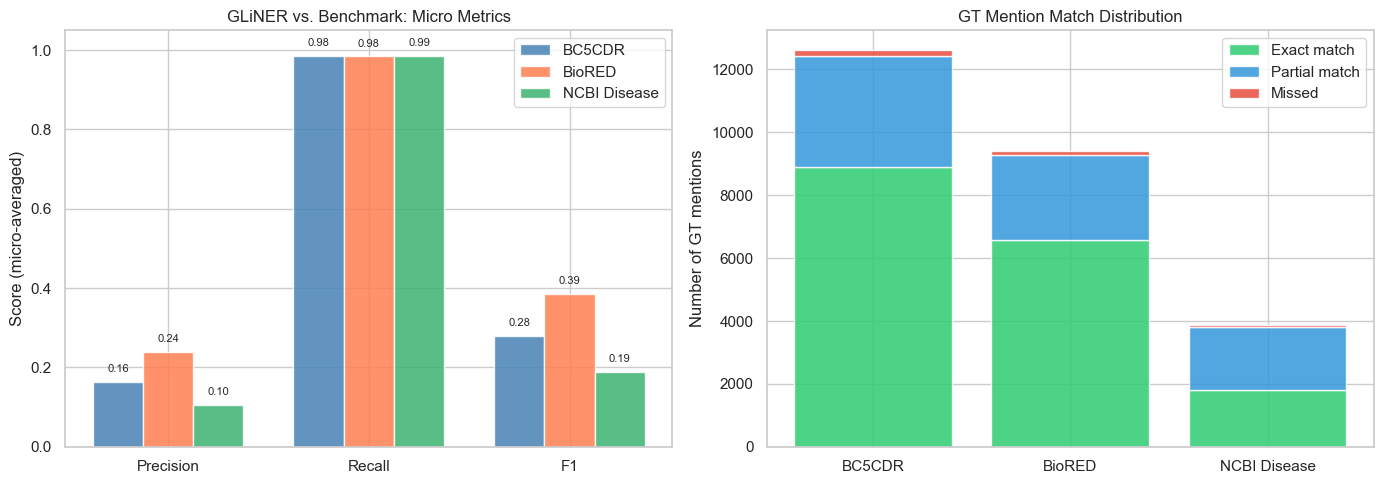

Saved: visualizations/pubmed_validation/metrics_and_match_distribution.png


In [20]:
# ── Figure 1: Metrics comparison + match distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: grouped bar chart of micro metrics
metrics = ['Precision', 'Recall', 'F1']
bc5cdr_vals = [bc5cdr_m['micro_precision'], bc5cdr_m['micro_recall'], bc5cdr_m['micro_f1']]
biored_vals  = [biored_m['micro_precision'],  biored_m['micro_recall'],  biored_m['micro_f1']]
ncbi_vals    = [ncbi_m['micro_precision'],    ncbi_m['micro_recall'],    ncbi_m['micro_f1']]

x = np.arange(len(metrics))
width = 0.25
ax = axes[0]
bars1 = ax.bar(x - width, bc5cdr_vals, width, label='BC5CDR',       color='steelblue', alpha=0.85)
bars2 = ax.bar(x,         biored_vals,  width, label='BioRED',        color='coral',     alpha=0.85)
bars3 = ax.bar(x + width, ncbi_vals,    width, label='NCBI Disease',  color='mediumseagreen', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score (micro-averaged)')
ax.set_title('GLiNER vs. Benchmark: Micro Metrics')
ax.legend()
for bar in list(bars1) + list(bars2) + list(bars3):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

# Right: stacked bar — match distribution
ax2 = axes[1]
datasets = ['BC5CDR', 'BioRED', 'NCBI Disease']
exacts   = [bc5cdr_m['total_exact'],   biored_m['total_exact'],   ncbi_m['total_exact']]
partials = [bc5cdr_m['total_partial'],  biored_m['total_partial'],  ncbi_m['total_partial']]
misseds  = [bc5cdr_m['total_missed'],   biored_m['total_missed'],   ncbi_m['total_missed']]
x2 = np.arange(len(datasets))
ax2.bar(x2, exacts,  label='Exact match',   color='#2ecc71', alpha=0.85)
ax2.bar(x2, partials, bottom=exacts,        label='Partial match', color='#3498db', alpha=0.85)
ax2.bar(x2, misseds, bottom=[e+p for e,p in zip(exacts, partials)],
        label='Missed', color='#e74c3c', alpha=0.85)
ax2.set_xticks(x2); ax2.set_xticklabels(datasets)
ax2.set_ylabel('Number of GT mentions')
ax2.set_title('GT Mention Match Distribution')
ax2.legend()

plt.tight_layout()
plt.savefig('../../visualizations/validation/pubmed_validation/metrics_and_match_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: visualizations/pubmed_validation/metrics_and_match_distribution.png')

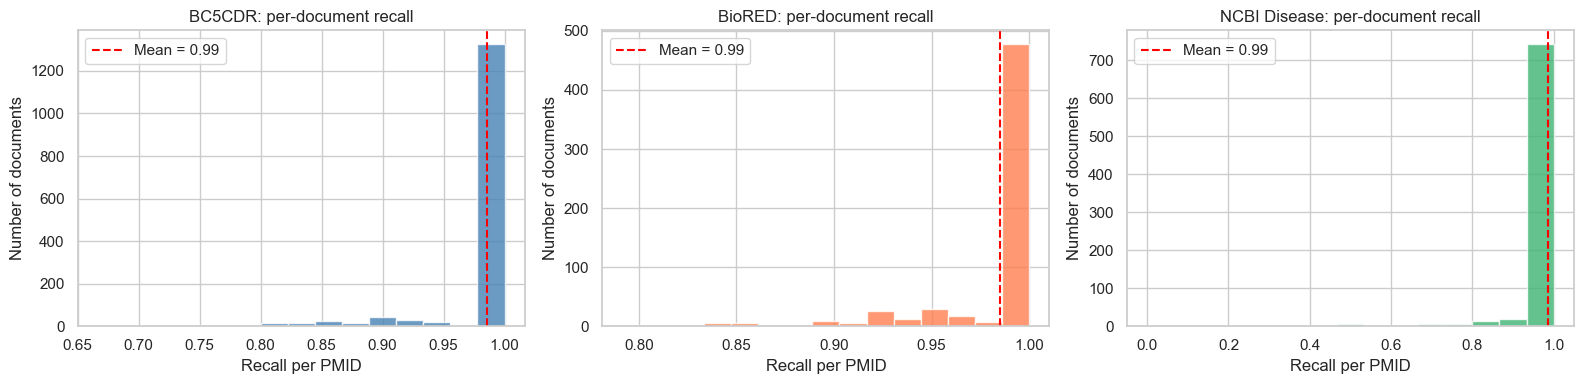

Saved: visualizations/pubmed_validation/per_pmid_recall_distribution.png


In [21]:
# ── Figure 2: Per-PMID recall distribution ──
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for ax, df, label, color in [
    (axes[0], bc5cdr_df, 'BC5CDR',       'steelblue'),
    (axes[1], biored_df, 'BioRED',        'coral'),
    (axes[2], ncbi_df,   'NCBI Disease',  'mediumseagreen'),
]:
    ax.hist(df['recall'], bins=15, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(df['recall'].mean(), color='red', linestyle='--',
               label=f"Mean = {df['recall'].mean():.2f}")
    ax.set_xlabel('Recall per PMID')
    ax.set_ylabel('Number of documents')
    ax.set_title(f'{label}: per-document recall')
    ax.legend()

plt.tight_layout()
plt.savefig('../../visualizations/validation/pubmed_validation/per_pmid_recall_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: visualizations/pubmed_validation/per_pmid_recall_distribution.png')

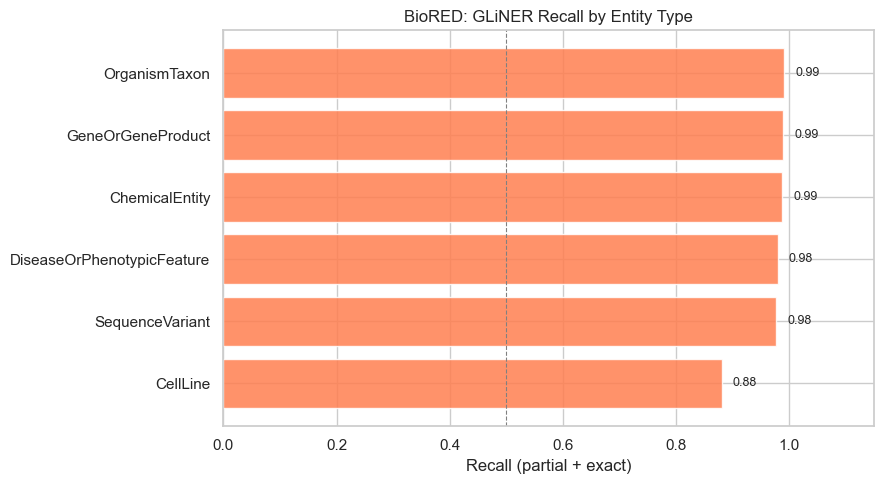

Saved: visualizations/pubmed_validation/biored_recall_by_entity_type.png


In [22]:
# ── Figure 3: BioRED recall by entity type ──
type_recall = type_summary[['recall']].sort_values('recall', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(type_recall.index, type_recall['recall'], color='coral', alpha=0.85)
ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel('Recall (partial + exact)')
ax.set_title('BioRED: GLiNER Recall by Entity Type')
ax.set_xlim(0, 1.15)
for bar in bars:
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../../visualizations/validation/pubmed_validation/biored_recall_by_entity_type.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: visualizations/pubmed_validation/biored_recall_by_entity_type.png')

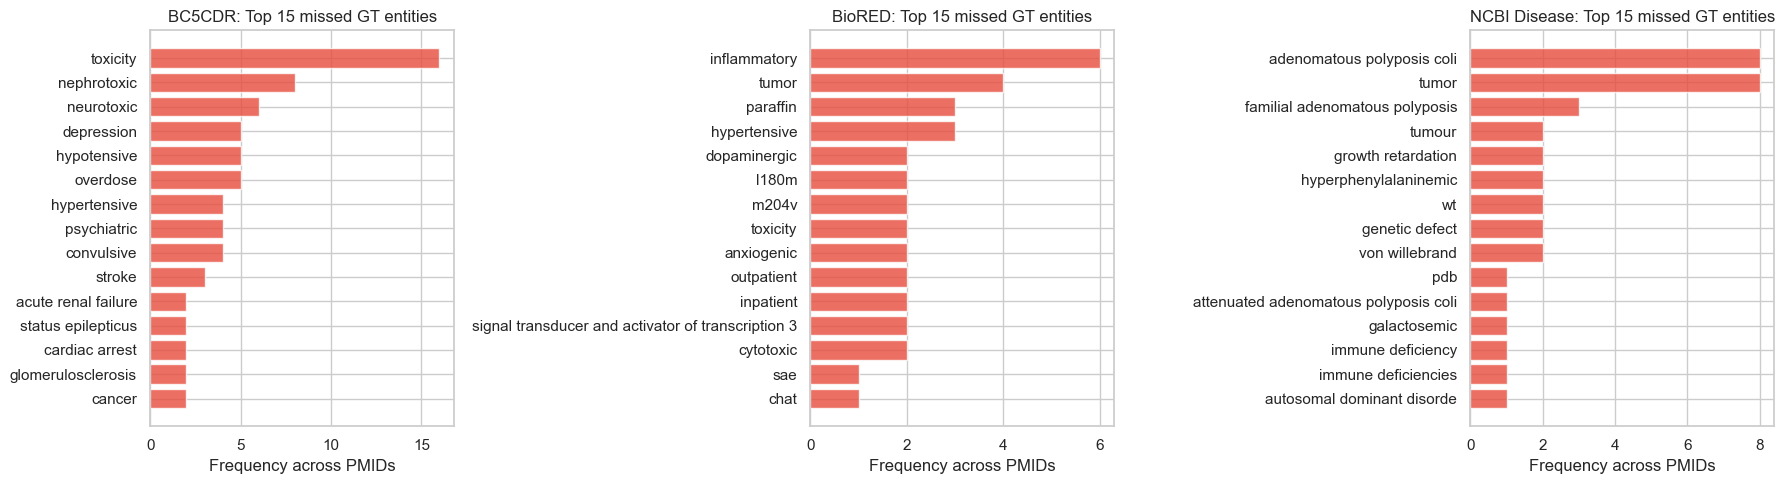

Saved: visualizations/pubmed_validation/top_missed_entities.png


In [23]:
# ── Figure 4: Top missed entities (all three benchmarks) ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, counts, title in [
    (axes[0], missed_bc5cdr_counts.head(15), 'BC5CDR: Top 15 missed GT entities'),
    (axes[1], missed_biored_counts.head(15),  'BioRED: Top 15 missed GT entities'),
    (axes[2], missed_ncbi_counts.head(15),    'NCBI Disease: Top 15 missed GT entities'),
]:
    ax.barh(counts.index[::-1], counts.values[::-1], color='#e74c3c', alpha=0.8)
    ax.set_xlabel('Frequency across PMIDs')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('../../visualizations/validation/pubmed_validation/top_missed_entities.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: visualizations/pubmed_validation/top_missed_entities.png')

## 9. Save Output Tables

In [24]:
list_cols = ['exact_mention_list', 'partial_mention_list', 'missed_mention_list']
bc5cdr_df.drop(columns=list_cols).to_csv('../../output/validation/pubmed_validation/bc5cdr_per_pmid.csv', index=False)
biored_df.drop(columns=list_cols).to_csv('../../output/validation/pubmed_validation/biored_per_pmid.csv', index=False)
ncbi_df.drop(columns=list_cols).to_csv('../../output/validation/pubmed_validation/ncbi_per_pmid.csv', index=False)
type_summary.to_csv('../../output/validation/pubmed_validation/biored_by_entity_type.csv')

summary_rows = []
for name, m, n_pmids in [
    ('BC5CDR',       bc5cdr_m, len(bc5cdr_overlap)),
    ('BioRED',       biored_m, len(biored_overlap)),
    ('NCBI Disease', ncbi_m,   len(ncbi_overlap)),
]:
    summary_rows.append({
        'benchmark':            name,
        'overlapping_pmids':    n_pmids,
        'total_gt_mentions':    m.get('total_gt', 'N/A'),
        'exact_matches':        m.get('total_exact', 'N/A'),
        'partial_matches':      m.get('total_partial', 'N/A'),
        'missed':               m.get('total_missed', 'N/A'),
        'total_gliner_terms':   m.get('total_gliner', 'N/A'),
        'gliner_terms_matched': m.get('total_gliner_matched', 'N/A'),
        'micro_precision':      round(m.get('micro_precision', float('nan')), 3),
        'micro_recall':         round(m.get('micro_recall', float('nan')), 3),
        'micro_f1':             round(m.get('micro_f1', float('nan')), 3),
        'macro_precision':      round(m.get('macro_precision', float('nan')), 3),
        'macro_recall':         round(m.get('macro_recall', float('nan')), 3),
        'macro_f1':             round(m.get('macro_f1', float('nan')), 3),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('../../output/validation/pubmed_validation/benchmark_summary.csv', index=False)
print('Saved to output/pubmed_validation/')
print(summary_df.to_string(index=False))

Saved to output/pubmed_validation/
   benchmark  overlapping_pmids  total_gt_mentions  exact_matches  partial_matches  missed  total_gliner_terms  gliner_terms_matched  micro_precision  micro_recall  micro_f1  macro_precision  macro_recall  macro_f1
      BC5CDR               1500              12614           8911             3513     190               99331                 16197            0.163         0.985     0.280            0.178         0.986     0.293
      BioRED                600               9421           6587             2685     149               49367                 11841            0.240         0.984     0.386            0.242         0.985     0.380
NCBI Disease                792               3864           1810             1999      55               52115                  5455            0.105         0.986     0.189            0.108         0.986     0.189


## 10. Summary of Findings

*Re-run using the dedicated benchmark JSON (`specialized_pubmed_samples_with_entities.json`) provided by Raphael, which contains GLiNER labels for all benchmark PMIDs. Coverage is now 100% for all three corpora, replacing the earlier random-sample analysis (BC5CDR 3.1%, BioRED 8.0%, NCBI Disease 0.0%).*

---

### 10.1 Evaluation Coverage

| Benchmark | PMIDs | GLiNER coverage |
|-----------|-------|----------------|
| BC5CDR | 1,500 | 100% |
| BioRED | 600 | 100% |
| NCBI Disease | 792 | 100% |

---

### 10.2 Overall Performance

| Benchmark | PMIDs | GT Mentions | Micro P | Micro R | Micro F1 |
|-----------|-------|-------------|---------|---------|----------|
| BC5CDR | 1,500 | 12,614 | 0.163 | 0.985 | 0.280 |
| BioRED | 600 | 9,421 | 0.240 | 0.984 | 0.386 |
| NCBI Disease | 792 | 3,864 | 0.105 | 0.986 | 0.189 |

GLiNER achieves near-perfect recall (~0.985) across all three benchmarks — consistent with the patent validation result (0.99). The high-recall / low-precision profile is robust across corpora and evaluation methodologies.

Precision varies across benchmarks: BioRED (0.240) > BC5CDR (0.163) > NCBI Disease (0.105). NCBI Disease is a disease-only corpus, so all non-disease GLiNER terms (chemicals, genes, cell types, etc.) count as false positives, explaining the lower precision. BioRED's higher precision reflects its broader six-type scope, which overlaps more closely with GLiNER's extraction vocabulary.

---

### 10.3 Performance by Entity Type (BioRED)

| Entity Type | Recall |
|-------------|--------|
| OrganismTaxon | 0.991 |
| GeneOrGeneProduct | 0.990 |
| ChemicalEntity | 0.987 |
| DiseaseOrPhenotypicFeature | 0.980 |
| SequenceVariant | 0.977 |
| CellLine | 0.880 |

At full scale the earlier recall gradient almost entirely flattens out. With the dedicated GLiNER labels, all six entity types achieve recall ≥ 0.88. Cell lines, the hardest type in the earlier analysis (recall = 0.000 at 17 annotations), now reach 0.880 across 92 annotations. The remaining gap is small and largely attributable to adjective-form and compound entity spans (e.g. *"signal transducer and activator of transcription 3"*) and rare abbreviations (*"SAE"*, *"CHAT"*) that GLiNER does not fragment into a matching substring.

---

### 10.4 Match Type Analysis

Partial matches remain substantial, especially for NCBI Disease:

| Benchmark | Matched (exact + partial) | Exact | Partial | Partial share | Exact-only recall |
|-----------|--------------------------|-------|---------|---------------|-------------------|
| BC5CDR | 12,424 / 12,614 | 8,911 | 3,513 | 28% | 0.707 |
| BioRED | 9,272 / 9,421 | 6,587 | 2,685 | 29% | 0.699 |
| NCBI Disease | 3,809 / 3,864 | 1,810 | 1,999 | 52% | 0.468 |

NCBI Disease has the highest partial-match share (52%), reflecting that disease names in older biomedical literature tend to be long, multi-word constructions (*"familial adenomatous polyposis"*, *"adenomatous polyposis coli"*) that GLiNER captures as a substring rather than as the complete span. If partial matching were disabled, NCBI Disease recall would drop from 0.986 to 0.468, underlining that the word-boundary partial matching logic is essential for this corpus.

---

### 10.5 Error Analysis

Missed entities are now rare (55–190 per benchmark across hundreds of articles). Common patterns:

- **Adjective forms of diseases**: *"hypertensive"*, *"convulsive"*, *"nephrotic"*, *"tumour"* — GLiNER extracts the noun stem (*hypertension*, *nephrotoxicity*) but not the adjectival form used in the ground truth.
- **Multi-word compound names**: *"adenomatous polyposis coli"* (missed 8×), *"familial adenomatous polyposis"* (missed 3×), *"signal transducer and activator of transcription 3"* — spans too long to be captured whole; partial matching covers most but the full string may not appear as a substring of any extracted term.
- **Abbreviations without expansion**: *"WT"*, *"PDB"*, *"SAE"*, *"CHAT"* — short tokens that are either below GLiNER's extraction confidence or too ambiguous without context.
- **Adjectival modifiers**: *"inflammatory"*, *"dopaminergic"*, *"cytotoxic"* — used as entity references in the ground truth but not extracted as standalone entities by GLiNER.

---

### 10.6 Comparison with Patent Validation

| Validation Setting | Precision | Recall | F1 |
|--------------------|-----------|--------|----|
| Patents (human annotation, claims only) | 0.27 | 0.99 | 0.42 |
| BC5CDR (chemicals + diseases, 1,500 PMIDs) | 0.163 | 0.985 | 0.280 |
| BioRED (6 entity types, 600 PMIDs) | 0.240 | 0.984 | 0.386 |
| NCBI Disease (diseases only, 792 PMIDs) | 0.105 | 0.986 | 0.189 |

At full scale, PubMed recall (0.984–0.986) is essentially identical to the patent recall (0.99). The earlier gap in the random-sample analysis was an artefact of low PMID coverage rather than a genuine domain difference in GLiNER's behaviour.

Precision differences are real and reflect scope mismatch: patent annotations covered only the focal terms in claim text (a narrow, curated vocabulary), while the PubMed benchmarks contain entity types GLiNER extracts freely (chemicals, organisms, generic biomedical concepts) that the narrower benchmark scope counts as false positives.

---

### 10.7 Conclusions

With full benchmark coverage, the evaluation confirms that GLiNER functions as a **near-complete recall extractor** (~98.5%) across all three biomedical NER corpora and both annotation styles (human + benchmark). Fewer than 200 ground-truth entities per benchmark are missed entirely.

Precision (~0.10–0.24) is the main weakness. GLiNER extracts substantially more terms than any single benchmark annotates, because it is not restricted to the entity types of interest to each corpus. For downstream use in focal-term extraction or literature mining, these results reinforce a **two-stage pipeline**: GLiNER for near-complete candidate generation, followed by a precision-oriented filtering step (entity-type confidence thresholds, a biomedical stop-word list, or minimum span length) to reduce noise before terms are used for indexing or matching.